In [143]:
import pandas as pd
from numpy import loadtxt
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import activations
from tensorflow.keras.metrics import AUC
from keras import regularizers
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

In [266]:
data = pd.read_csv('data/train_data.csv')
data.head()

,ID,Bankruptcy,Realized.Sales.Gross.Profit.Growth.Rate,Operating.Expense.Rate,Operating.Profit.Per.Share..Yuan...,Gross.Profit.to.Sales,Tax.rate..A.,Current.Liability.to.Liability,Continuous.Net.Profit.Growth.Rate,Long.term.Liability.to.Current.Assets,...,Per.Share.Net.profit.before.tax..Yuan...,Continuous.interest.rate..after.tax.,Liability.Assets.Flag,Working.Capital.to.Total.Assets,Degree.of.Financial.Leverage..DFL.,Operating.Gross.Margin,Contingent.liabilities.Net.worth,Operating.Profit.Growth.Rate,Cash.Flow.to.Liability,Quick.Assets.Total.Assets
0,1,0,0.087661,1.900349e-04,0.131094,0.583345,0.000000,0.815892,0.395719,0.089276,...,0.223720,0.801737,0,0.839112,0.036551,0.591350,0.007401,0.913175,0.489822,0.138714
1,2,0,0.021892,5.371576e-04,0.086167,0.695478,0.209649,0.768636,0.163505,0.000000,...,0.324763,0.791203,0,0.908450,0.126752,0.766066,0.020514,0.849241,0.550247,0.704211
2,3,0,0.102249,2.178329e-04,0.157755,0.766934,0.272061,0.643316,0.181571,0.010180,...,0.360892,0.803126,0,0.865943,0.018152,0.687211,0.004363,0.865814,0.447168,0.398086
3,4,0,0.029972,4.915756e+10,0.249279,0.611580,0.288357,0.752782,0.409196,0.018603,...,0.152445,0.824732,0,0.806254,0.051284,0.715973,0.014162,0.843357,0.485163,0.617386
4,6,0,0.021164,1.206001e-04,0.239817,0.614250,0.000000,0.559498,0.286989,0.148687,...,0.217282,0.787010,0,0.769843,0.012872,0.704043,0.003050,0.884905,0.422001,0.187121


In [267]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,2:], data.iloc[:,1], test_size=0.20)

print(f'Train size: {X_train.shape}')
print(f'Test size: {X_test.shape}')

Train size: (1640, 63)
Test size: (410, 63)


In [268]:
print(f'Train cases: {y_train.value_counts()}')
print(f'Test cases: {y_test.value_counts()}')

Train cases: Bankruptcy
0    1593
1      47
Name: count, dtype: int64
Test cases: Bankruptcy
0    395
1     15
Name: count, dtype: int64


In [269]:
import numpy as np
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
import warnings
warnings.filterwarnings('ignore')

# 1. Transformador para manejar outliers
class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3):
        self.threshold = threshold
        self.means_ = None
        self.stds_ = None
        self.is_numeric_ = None
        
    def fit(self, X, y=None):
        # Guardar cuáles columnas son numéricas
        self.is_numeric_ = {col: np.issubdtype(X[col].dtype, np.number) 
                           for col in X.columns}
        
        # Calcular media y desviación estándar solo para columnas numéricas
        self.means_ = {}
        self.stds_ = {}
        
        for col in X.columns:
            if self.is_numeric_[col]:
                self.means_[col] = X[col].mean()
                self.stds_[col] = X[col].std()
                
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        
        for col in X.columns:
            if self.is_numeric_[col] and self.stds_[col] > 0:
                upper_limit = self.means_[col] + self.threshold * self.stds_[col]
                lower_limit = self.means_[col] - self.threshold * self.stds_[col]
                
                # Recortar valores por encima y por debajo de los límites
                X_transformed[col] = X_transformed[col].clip(lower=lower_limit, upper=upper_limit)
                
        return X_transformed

# 2. Transformador para estandarización que maneja DataFrames
class DataFrameStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.scaler = StandardScaler()
        self.columns_ = None
        self.is_numeric_ = None
        
    def fit(self, X, y=None):
        # Guardar nombres de columnas
        self.columns_ = X.columns.tolist()
        
        # Identificar columnas numéricas
        self.is_numeric_ = {col: np.issubdtype(X[col].dtype, np.number) 
                           for col in X.columns}
        
        # Filtrar solo columnas numéricas para estandarizar
        numeric_cols = [col for col in self.columns_ if self.is_numeric_[col]]
        if numeric_cols:
            self.scaler.fit(X[numeric_cols])
            
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        
        # Filtrar solo columnas numéricas para estandarizar
        numeric_cols = [col for col in self.columns_ if self.is_numeric_[col]]
        if numeric_cols:
            X_transformed[numeric_cols] = self.scaler.transform(X[numeric_cols])
            
        return X_transformed

# 3. Transformador para selección de características basado en Gini/IV
class GiniSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.4, max_features=20):
        self.threshold = threshold
        self.max_features = max_features
        self.feature_importances_ = None
        self.selected_features_ = None
        
    def _calculate_gini(self, X, y):
        # Inicializar diccionario para almacenar los valores de Gini
        gini_values = {}
        
        # Convertir y a Series si es un array
        if not isinstance(y, pd.Series):
            y = pd.Series(y)
        
        # Calcular Gini para cada variable
        for col in X.columns:
            if np.issubdtype(X[col].dtype, np.number):
                try:
                    # Ordenar los valores de X y calcular la curva de Lorenz
                    # usando el método del área bajo la curva
                    df_temp = pd.DataFrame({'X': X[col], 'y': y})
                    df_temp = df_temp.sort_values('X')
                    df_temp['y_cumsum'] = df_temp['y'].cumsum() / df_temp['y'].sum()
                    df_temp['X_cumsum'] = np.linspace(0, 1, len(df_temp))
                    
                    # Calcular el área bajo la curva
                    auc = np.trapz(df_temp['y_cumsum'], df_temp['X_cumsum'])
                    
                    # Gini = 2*AUC - 1 (normalizado entre -1 y 1)
                    gini = 2 * auc - 1
                    
                    # Valor absoluto del Gini para ordenamiento
                    gini_values[col] = abs(gini)
                except:
                    gini_values[col] = 0
            else:
                gini_values[col] = 0
                
        return gini_values
    
    def fit(self, X, y):
        # Calcular valores de Gini para todas las características
        self.feature_importances_ = self._calculate_gini(X, y)
        
        # Ordenar características por importancia
        sorted_features = sorted(self.feature_importances_.items(), 
                                 key=lambda x: x[1], reverse=True)
        
        # Seleccionar características que cumplen el umbral y el número máximo
        selected_features = []
        for feature, importance in sorted_features:
            if importance >= self.threshold and len(selected_features) < self.max_features:
                selected_features.append(feature)
                
        # Si no hay suficientes características que superen el umbral, tomar las top max_features
        if not selected_features or len(selected_features) < min(self.max_features, len(X.columns)):
            top_features = [feature for feature, _ in sorted_features[:self.max_features]]
            selected_features = list(set(selected_features + top_features))[:self.max_features]
            
        self.selected_features_ = selected_features
        return self
    
    def transform(self, X):
        # Devolver solo las columnas seleccionadas
        return X[self.selected_features_]

# 4. Transformador para eliminar variables correlacionadas
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8, method='pearson'):
        self.threshold = threshold
        self.method = method
        self.features_to_drop_ = None
        self.feature_importances_ = None
        
    def fit(self, X, y=None):
        # Calcular matriz de correlación
        corr_matrix = X.corr(method=self.method)
        
        # Inicializar conjunto de características a eliminar
        self.features_to_drop_ = set()
        
        # Si tenemos importancia de características de un paso anterior, usarlas
        # De lo contrario, consideramos que todas las características tienen la misma importancia
        if hasattr(self, 'feature_importances_') and self.feature_importances_ is not None:
            importances = self.feature_importances_
        else:
            importances = {col: 1.0 for col in X.columns}
            
        # Recorrer la matriz triangular superior
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > self.threshold:
                    col_i = corr_matrix.columns[i]
                    col_j = corr_matrix.columns[j]
                    
                    # Eliminar la característica con menor importancia
                    if importances.get(col_i, 0) <= importances.get(col_j, 0):
                        self.features_to_drop_.add(col_i)
                    else:
                        self.features_to_drop_.add(col_j)
        
        return self
    
    def set_feature_importances(self, importances):
        """Establece la importancia de las características desde un paso anterior"""
        self.feature_importances_ = importances
        return self
    
    def transform(self, X):
        # Filtrar las características que no fueron eliminadas
        return X.drop(columns=list(self.features_to_drop_))

# Función para crear y ejecutar el pipeline completo
def crear_pipeline_preprocesamiento(X_train, y_train, 
                                   outlier_threshold=3,
                                   gini_threshold=0.1, 
                                   max_features=20,
                                   corr_threshold=0.7):
    """
    Crea y ejecuta un pipeline de preprocesamiento para modelado predictivo.
    
    Parámetros:
    -----------
    X_train : DataFrame
        Conjunto de datos de entrenamiento (características)
    y_train : Series o array
        Variable objetivo para el conjunto de entrenamiento
    outlier_threshold : float, default=3
        Umbral en desviaciones estándar para recortar outliers
    gini_threshold : float, default=0.1
        Umbral de Gini absoluto para selección de características
    max_features : int, default=20
        Número máximo de características a seleccionar
    corr_threshold : float, default=0.8
        Umbral de correlación para eliminar características redundantes
        
    Retorna:
    --------
    pipeline : Pipeline
        Pipeline entrenado
    X_train_transformed : DataFrame
        Datos de entrenamiento transformados
    """
    # Crear los componentes del pipeline
    outlier_clipper = OutlierClipper(threshold=outlier_threshold)
    scaler = DataFrameStandardScaler()
    gini_selector = GiniSelector(threshold=gini_threshold, max_features=max_features)
    correlation_filter = CorrelationFilter(threshold=corr_threshold)
    
    # Crear el pipeline
    pipeline = Pipeline([
        ('outlier_clipper', outlier_clipper),
        ('scaler', scaler),  # Añadido el paso de estandarización
        ('gini_selector', gini_selector),
        ('correlation_filter', correlation_filter)
    ])
    
    # Entrenar el pipeline
    X_train_transformed = pipeline.fit_transform(X_train, y_train)
    
    # Transferir las importancias de las características del selector al filtro de correlación
    correlation_filter.set_feature_importances(gini_selector.feature_importances_)
    
    # Imprimir información del proceso
    print(f"Variables originales: {X_train.shape[1]}")
    print(f"Variables después de selección por Gini: {len(gini_selector.selected_features_)}")
    print(f"Variables después de filtrar correlacionadas: {X_train_transformed.shape[1]}")
    print("\nTop 10 variables por importancia Gini:")
    sorted_importances = sorted(gini_selector.feature_importances_.items(), 
                               key=lambda x: x[1], reverse=True)[:10]
    for feature, importance in sorted_importances:
        print(f"  {feature}: {importance:.4f}")
    
    print("\nVariables eliminadas por alta correlación:")
    for feature in correlation_filter.features_to_drop_:
        print(f"  {feature}")
    
    return pipeline, X_train_transformed

# Ejemplo de uso
# (Descomenta estas líneas para ejecutar el ejemplo con tus datos)
pipeline, X_train_transformed = crear_pipeline_preprocesamiento(
    X_train, y_train, 
    outlier_threshold=3,
    gini_threshold=0.3,
    max_features=20,
    corr_threshold=0.6
)

# Para transformar datos de prueba
X_test_transformed = pipeline.transform(X_test)

Variables originales: 63
Variables después de selección por Gini: 20
Variables después de filtrar correlacionadas: 18

Top 10 variables por importancia Gini:
  Retained.Earnings.to.Total.Assets: 0.5382
  Working.Capital.to.Total.Assets: 0.5363
  Tax.rate..A.: 0.4990
  Cash.Total.Assets: 0.4990
  ROA.B..before.interest.and.depreciation.after.tax: 0.4060
  Quick.Assets.Total.Assets: 0.4003
  Total.debt.Total.net.worth: 0.3982
  Current.Liability.to.Assets: 0.3942
  Long.term.Liability.to.Current.Assets: 0.3935
  Cash.Current.Liability: 0.3902

Variables eliminadas por alta correlación:
  Operating.Profit.Rate
  Current.Liability.to.Current.Assets


In [271]:
model1 = Sequential()
model1.add(Dense(16, input_dim=X_train_transformed.shape[1], activation='sigmoid'))
model1.add(Dense(8, activation='sigmoid'))
model1.add(Dense(1, activation='sigmoid'))

model2 = Sequential()
model2.add(Dense(16, input_dim=X_train_transformed.shape[1], activation='relu'))
model2.add(Dense(8, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model3 = Sequential()
model3.add(Dense(16, input_dim=X_train_transformed.shape[1], activation='softplus'))
model3.add(Dense(8, activation='softplus'))
model3.add(Dense(1, activation='sigmoid'))

In [ ]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [273]:
history1=model1.fit(X_train_transformed, y_train, epochs=10, batch_size=10 )
history2=model2.fit(X_train_transformed, y_train, epochs=10, batch_size=10 )
history3=model3.fit(X_train_transformed, y_train, epochs=10, batch_size=10 )

Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.8989 - loss: 0.5656   
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - accuracy: 0.9696 - loss: 0.2716
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.9745 - loss: 0.1799
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - accuracy: 0.9697 - loss: 0.1551
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - accuracy: 0.9708 - loss: 0.1344
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step - accuracy: 0.9691 - loss: 0.1305
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - accuracy: 0.9783 - loss: 0.0984
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - accuracy: 0.9680 - loss: 0.1211
Epoch 9/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - accuracy: 0.9735 - loss: 0.1022
Epoch 10/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - accuracy: 0.9754 - loss: 0.0985
Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - accuracy: 0.8961 - loss: 0.3462
Epoch 2/10
164/164 ━━━━━━━━━

In [274]:
_, accuracy = model1.evaluate(X_test_transformed, y_test)
print('Accuracy: %.2f' % (accuracy*100))

_, accuracy = model2.evaluate(X_test_transformed, y_test)
print('Accuracy: %.2f' % (accuracy*100))

_, accuracy = model3.evaluate(X_test_transformed, y_test)
print('Accuracy: %.2f' % (accuracy*100))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.9502 - loss: 0.1551
Accuracy: 96.34
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - accuracy: 0.9575 - loss: 0.1207
Accuracy: 96.59
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - accuracy: 0.9640 - loss: 0.1049
Accuracy: 96.59


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC para el modelo 1: 0.9389
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC para el modelo 2: 0.8965
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
AUC para el modelo 3: 0.9257


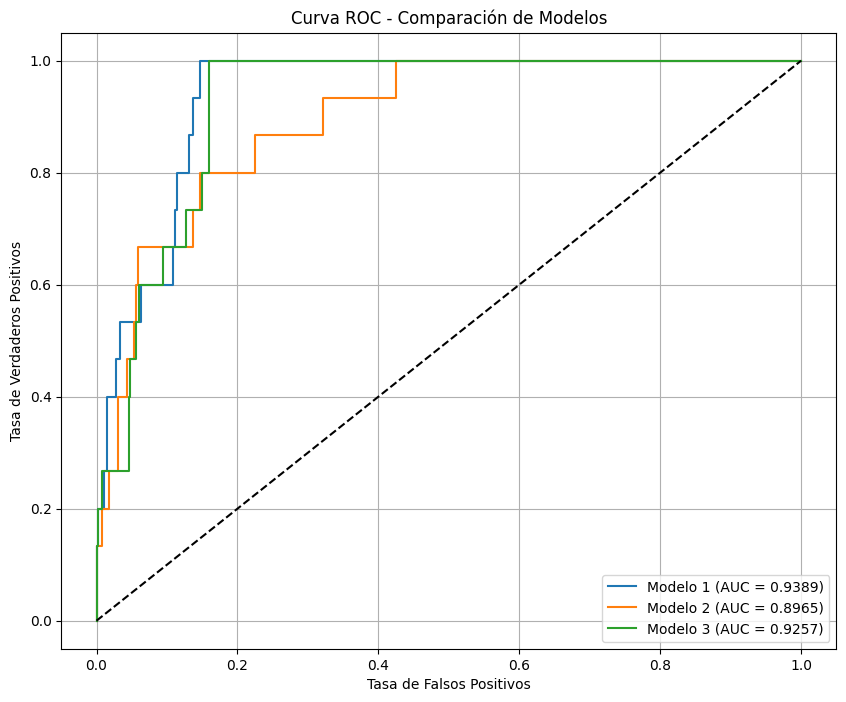

In [275]:
from sklearn.metrics import roc_auc_score, roc_curve

# Modelo 1
predicciones1_prob = model1.predict(X_test_transformed)  # Mantén las probabilidades sin redondear
auc1 = roc_auc_score(y_test, predicciones1_prob)
print(f"AUC para el modelo 1: {auc1:.4f}")

# Modelo 2
predicciones2_prob = model2.predict(X_test_transformed)
auc2 = roc_auc_score(y_test, predicciones2_prob)
print(f"AUC para el modelo 2: {auc2:.4f}")

# Modelo 3
predicciones3_prob = model3.predict(X_test_transformed)
auc3 = roc_auc_score(y_test, predicciones3_prob)
print(f"AUC para el modelo 3: {auc3:.4f}")

# También puedes visualizar las curvas ROC
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Curva ROC para modelo 1
fpr1, tpr1, _ = roc_curve(y_test, predicciones1_prob)
plt.plot(fpr1, tpr1, label=f'Modelo 1 (AUC = {auc1:.4f})')

# Curva ROC para modelo 2
fpr2, tpr2, _ = roc_curve(y_test, predicciones2_prob)
plt.plot(fpr2, tpr2, label=f'Modelo 2 (AUC = {auc2:.4f})')

# Curva ROC para modelo 3
fpr3, tpr3, _ = roc_curve(y_test, predicciones3_prob)
plt.plot(fpr3, tpr3, label=f'Modelo 3 (AUC = {auc3:.4f})')

# Línea de referencia (modelo aleatorio)
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend()
plt.grid(True)
plt.show()

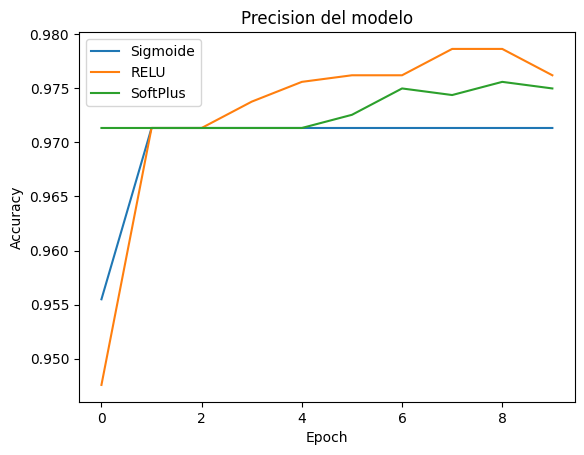

In [276]:
plt.figure(1)
# Graficar accuracy del modelo
plt.title('Precision del modelo')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.plot(history1.history['accuracy'])
plt.plot(history2.history['accuracy'])
plt.plot(history3.history['accuracy'])

plt.legend(['Sigmoide', 'RELU', 'SoftPlus'], loc='upper left')
plt.show()

In [281]:

X_train_transformed = pipeline.transform(data.iloc[:,2:])

model1 = Sequential()
model1.add(Dense(16, input_dim=X_train_transformed.shape[1], activation='sigmoid'))
model1.add(Dense(8, activation='sigmoid'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history1=model1.fit(X_train_transformed, data.iloc[:,1], epochs=10, batch_size=10 )


Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - accuracy: 0.5035 - loss: 0.6663   
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.9755 - loss: 0.2579
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step - accuracy: 0.9628 - loss: 0.1849
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - accuracy: 0.9754 - loss: 0.1273
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - accuracy: 0.9669 - loss: 0.1345
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - accuracy: 0.9655 - loss: 0.1299
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - accuracy: 0.9680 - loss: 0.1214
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 365us/step - accuracy: 0.9713 - loss: 0.1044
Epoch 9/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - accuracy: 0.9665 - loss: 0.1154
Epoch 10/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 366us/step - accuracy: 0.9695 - loss: 0.1016


In [282]:
test_data = pd.read_csv('data/test_data.csv')
test_data

,ID,Realized.Sales.Gross.Profit.Growth.Rate,Operating.Expense.Rate,Operating.Profit.Per.Share..Yuan...,Gross.Profit.to.Sales,Tax.rate..A.,Current.Liability.to.Liability,Continuous.Net.Profit.Growth.Rate,Long.term.Liability.to.Current.Assets,Total.assets.to.GNP.price,...,Per.Share.Net.profit.before.tax..Yuan...,Continuous.interest.rate..after.tax.,Liability.Assets.Flag,Working.Capital.to.Total.Assets,Degree.of.Financial.Leverage..DFL.,Operating.Gross.Margin,Contingent.liabilities.Net.worth,Operating.Profit.Growth.Rate,Cash.Flow.to.Liability,Quick.Assets.Total.Assets
0,5,0.055077,1.064430e-02,0.131220,0.657541,0.118122,0.771297,0.366505,0.018675,0.001246,...,0.197730,0.786381,0,0.828263,0.024649,0.645659,0.052743,0.913336,0.557402,0.360819
1,14,0.020286,6.654634e+07,0.247104,0.746134,0.000000,0.697656,0.313514,0.126093,0.006813,...,0.254563,0.850153,0,0.684968,0.075233,0.723486,0.003821,0.851428,0.584835,0.058199
2,16,0.040610,8.415991e+08,0.164832,0.718794,0.130647,0.398228,0.239002,0.122627,0.002547,...,0.186794,0.808544,0,0.888590,0.078625,0.737439,0.070270,0.832491,0.409327,0.449420
3,26,0.067641,1.344961e-04,0.153400,0.741510,0.000000,0.842550,0.348637,0.007500,0.000219,...,0.401842,0.830902,0,0.800685,0.158704,0.610681,0.012037,0.824596,0.561291,0.449031
4,28,0.017546,6.125562e-03,0.208468,0.743188,0.317456,0.387746,0.175101,0.039756,0.008112,...,0.329068,0.799609,0,0.824782,0.136387,0.637626,0.003518,0.900079,0.477007,0.395706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2518,0.037330,3.381351e+10,0.285901,0.701968,0.444407,0.918184,0.183372,0.000338,0.004595,...,0.284397,0.850451,0,0.809300,0.033507,0.758525,0.008149,0.836865,0.620500,0.453694
496,2523,0.102056,2.814351e-04,0.158274,0.771253,0.057874,0.725923,0.181533,0.040638,0.064586,...,0.371915,0.802988,0,0.794917,0.018306,0.692694,0.003946,0.865667,0.447704,0.066660
497,2529,0.013648,3.712747e-04,0.087591,0.598455,0.000000,0.650754,0.295609,0.156821,0.010683,...,0.182644,0.858830,0,0.713373,0.115433,0.631318,0.002632,0.893523,0.421889,0.280992
498,2530,0.031334,8.250494e-05,0.160728,0.759960,0.224295,1.000000,0.378352,0.000000,0.001199,...,0.390684,0.861165,0,0.785428,0.015998,0.677255,0.012348,0.865474,0.533708,0.852414


In [283]:
X_oos = test_data.iloc[:,1:]

X_oos_transformed = pipeline.transform(X_oos)

predicciones = model1.predict(X_oos_transformed)

predicciones

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[0.01719244],
       [0.09084925],
       [0.02053169],
       [0.01723674],
       [0.01818148],
       [0.01764011],
       [0.01651687],
       [0.01976768],
       [0.05901941],
       [0.0166419 ],
       [0.04561374],
       [0.02812586],
       [0.02922211],
       [0.1331869 ],
       [0.01923111],
       [0.0162361 ],
       [0.02074056],
       [0.13600278],
       [0.01800615],
       [0.03892265],
       [0.01690486],
       [0.02173067],
       [0.0164254 ],
       [0.02164132],
       [0.0201021 ],
       [0.02328172],
       [0.02735893],
       [0.0182035 ],
       [0.01883707],
       [0.01664448],
       [0.02930593],
       [0.01777652],
       [0.01647981],
       [0.02662679],
       [0.01691934],
       [0.01707292],
       [0.01686692],
       [0.01632378],
       [0.01993435],
       [0.01654644],
       [0.02973255],
       [0.01628409],
       [0.05856175],
       [0.01646591],
       [0.01620224],
       [0.02511048],
       [0.02029829],
       [0.016

In [284]:
test_data['Bankruptcy'] = predicciones

test_data[['ID', 'Bankruptcy']]

,ID,Bankruptcy
0,5,0.017192
1,14,0.090849
2,16,0.020532
3,26,0.017237
4,28,0.018181
...,...,...
495,2518,0.016822
496,2523,0.039603
497,2529,0.087681
498,2530,0.017328


In [285]:
test_data[['ID', 'Bankruptcy']].to_csv('predictions/submit3.csv', index=False)